# CorePromoter model clean workflow

This notebook is a simplified version of Model_CorePromoter_v0.ipynb. It keeps the core workflow only:

1. setup and utilities
2. training-data assembly
3. model definition
4. train/test split and training
5. train/test evaluation
6. trained filter logos
7. NN-based assembled-sequence scan

BPM scanning and old debug cells are intentionally removed.


In [25]:
## Setup
import os
import random
import itertools
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

import logomaker
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

from util import getPFM, Motif2Seqs, sci_ticks

SEED = 777

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## Utility functions

These helper functions are shared by training and scan cells.


In [26]:
def stratified_sample(df, col, counts, seed=SEED):
    df = df.copy()
    rng_bins = pd.cut(df[col], bins=len(counts))
    parts = []
    for grp, cnt in zip(sorted(rng_bins.dropna().unique()), counts):
        sub = df[rng_bins == grp]
        if len(sub) == 0:
            continue
        parts.append(sub.sample(cnt, replace=True, random_state=seed))
    return pd.concat(parts)


def dna_one_hot(seq, flatten=False):
    mapping = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        '-': [-1, -1, -1, -1],
        'N': [1/4, 1/4, 1/4, 1/4],
    }
    one_hot = np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]).T
    return one_hot.flatten() if flatten else one_hot


## Build training dataset

The dataframe name is kept as `df_train` for compatibility, but it represents the full sampled dataset before train/test split.


In [27]:
TABLE_DIR = "../tables"
LIBRARY_ORDER = ["PL17", "SL16", "SL17", "SL18", "DL", "UL", "ITS"]


def PpurR(seq):
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCAC' + seq[:6] + 'TTTTCGTCAAGATCGGC' + seq[-6:] + 'TCCACGCTTACTAAATCTATGT'


def SL16(seq):
    return 'ACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT' + seq + 'TATTATGCACACCCCTAAATCTATGTAG'


def SL17(seq):
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC' + seq + 'TAACCTTCCACGCTTACTAAATCTATGT'


def SL18(seq):
    return 'TCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA' + seq + 'GATAATGTGTGGAATTAAATCTATGTA'


def DL(seq):
    return 'AGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC' + seq + 'CAAAATCTATGTAGCT'


def UL(seq):
    return 'CAGAAAAAG' + seq + 'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCT----------'


def ITS(seq):
    return 'AGCAGCGTTAAATTCACGCCCTTCTCTTGAGACATTTCTTTTGCACTGGTAAACTAAATC' + seq + 'GTCCCAGGCT'


def build_training_dataframe():
    df_PL17 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/PL.pkl"), 'LogGFP', [2000, 2000, 2000, 1000, 1000, 1000, 500, 500])[['rep1', 'rep2', 'LogGFP']]
    df_PL17['Sequence'] = df_PL17.index.map(PpurR)
    df_PL17['Library'] = "PL17"

    df_SL16 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL16.pkl"), 'LogGFP', [300] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL16['Sequence'] = df_SL16.index.map(SL16)
    df_SL16['Library'] = "SL16"

    df_SL17 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL17.pkl"), 'LogGFP', [400] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL17['Sequence'] = df_SL17.index.map(SL17)
    df_SL17['Library'] = "SL17"

    df_SL18 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL18.pkl"), 'LogGFP', [300] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL18['Sequence'] = df_SL18.index.map(SL18)
    df_SL18['Library'] = "SL18"

    df_DL = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/DL.pkl"), 'LogGFP', [200] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_DL['Sequence'] = df_DL.index.map(DL)
    df_DL['Library'] = "DL"

    df_UL = pd.read_pickle(f"{TABLE_DIR}/UL.pkl")
    df_UL = df_UL[(df_UL['LogGFP'] > 1) & (df_UL['LogGFP'] < 4)]
    df_UL = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
    df_UL['Sequence'] = df_UL.index.map(UL)
    df_UL['Library'] = "UL"

    df_ITS = pd.read_pickle(f"{TABLE_DIR}/ITS.pkl")
    df_ITS = stratified_sample(df_ITS, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
    df_ITS['Sequence'] = df_ITS.index.map(ITS)
    df_ITS['Library'] = "ITS"

    return pd.concat([df_PL17, df_SL16, df_SL17, df_SL18, df_DL, df_UL, df_ITS]).reset_index(drop=True)


df_train = build_training_dataframe()
print(df_train.shape)
display(df_train.groupby('Library').size().reindex(LIBRARY_ORDER))
df_train.head()


(34000, 5)


Library
PL17    10000
SL16     3000
SL17     4000
SL18     3000
DL       2000
UL       6000
ITS      6000
dtype: int64

,rep1,rep2,LogGFP,Sequence,Library
0,0.446169,0.409302,0.427736,CACAGCAGCAGTCAGGTACTCCAGTCCACACATATTTTTCGTCAAG...,PL17
1,0.622179,0.467092,0.544635,CACAGCAGCAGTCAGGTACTCCAGTCCACGGAACATTTTCGTCAAG...,PL17
2,0.502947,NaN,0.502947,CACAGCAGCAGTCAGGTACTCCAGTCCACATATGTTTTTCGTCAAG...,PL17
3,0.664487,0.406002,0.535245,CACAGCAGCAGTCAGGTACTCCAGTCCACATAAGATTTTCGTCAAG...,PL17
4,0.545845,NaN,0.545845,CACAGCAGCAGTCAGGTACTCCAGTCCACGTTAGGTTTTCGTCAAG...,PL17


## Model definition

The model keeps the original structure: 8 first-layer filters and 3 architecture channels for spacer flexibility.


In [28]:
class DNAFunctionPredictor(nn.Module):
    def __init__(self, seq_length, num_conds):
        super().__init__()
        self.seq_length = seq_length
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=8, stride=1)
        self._initialize_conv1()

        self.conv2 = nn.Conv1d(in_channels=8, out_channels=3, kernel_size=65, stride=1)
        self._initialize_conv2()

        self.conds_bias = nn.Parameter(torch.zeros(num_conds))
        self.param_max = nn.Parameter(torch.tensor(np.log(1000.0)), requires_grad=True)
        self.param_min = nn.Parameter(torch.tensor(np.log(0.5)), requires_grad=True)
        self.param_e0 = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def _initialize_conv1(self):
        motifs = [
            "AAAATTTG",
            "GAAAATAG",
            "TTGACATT",
            "NGGCCTAA",
            "ATGGGGTA",
            "TAATTTTT",
            "AAAGCAAA",
            "AAAAAGNN",
        ]
        custom_weights = np.stack([
            getPFM(Motif2Seqs(motif), ratios=True).values.T for motif in motifs
        ], axis=0)
        self.conv1.weight = nn.Parameter(torch.tensor(custom_weights, dtype=torch.float32), requires_grad=True)
        self.conv1.bias.data.zero_()
        self.conv1.bias.requires_grad = False

    def _initialize_conv2(self):
        filter1_weights = np.zeros((8, 65))
        filter2_weights = np.zeros((8, 65))
        filter3_weights = np.zeros((8, 65))

        filter1_weights[0, 3], filter1_weights[1, 11], filter1_weights[2, 22], filter1_weights[3, 30], filter1_weights[4, 38], filter1_weights[5, 46], filter1_weights[6, 54], filter1_weights[7, 62] = 1, 1, 1, 1, 1, 1, 1, 1
        filter2_weights[0, 3], filter2_weights[1, 11], filter2_weights[2, 22], filter2_weights[3, 31], filter2_weights[4, 39], filter2_weights[5, 47], filter2_weights[6, 55], filter2_weights[7, 63] = 1, 1, 1, 1, 1, 1, 1, 1
        filter3_weights[0, 3], filter3_weights[1, 11], filter3_weights[2, 22], filter3_weights[3, 32], filter3_weights[4, 40], filter3_weights[5, 48], filter3_weights[6, 56], filter3_weights[7, 64] = 1, 1, 1, 1, 1, 1, 1, 1

        custom_weights = np.stack([filter1_weights, filter2_weights, filter3_weights], axis=0)
        self.conv2.weight.data = torch.tensor(custom_weights, dtype=torch.float32)
        self.conv2.weight.requires_grad = False
        self.conv2.bias.data.zero_()
        self.conv2.bias.requires_grad = True

    def energy(self, dna_seq):
        x = self.conv1(dna_seq)
        x = self.conv2(x)
        return torch.max(x.reshape(x.size(0), -1), dim=1, keepdim=True).values

    def energy2expression(self, x):
        beta = 1 / (0.001987 * 310)
        boltz_weight = torch.exp(beta * (x + self.param_e0))
        max_expr = torch.exp(self.param_max)
        min_expr = torch.exp(self.param_min)
        return torch.log(min_expr + max_expr * boltz_weight / (1 + boltz_weight))

    def forward(self, dna_seq, conds):
        x = self.energy(dna_seq)
        x = x + torch.matmul(conds, self.conds_bias.unsqueeze(1))
        return self.energy2expression(x)


## Train/test split and tensors


In [ ]:
TEST_SIZE = 0.2
STRATIFY_BY_LIBRARY = False
BATCH_SIZE = 32

library_categorical = pd.Categorical(df_train['Library'], categories=LIBRARY_ORDER)
conds = pd.get_dummies(library_categorical).to_numpy(dtype=np.float32)
dna_seq = np.array(list(df_train['Sequence'].apply(dna_one_hot)), dtype=np.float32)
target_loge = (df_train['LogGFP'].values * np.log(10)).astype(np.float32)
libraries = df_train['Library'].values
indices = np.arange(len(df_train))

stratify_labels = libraries if STRATIFY_BY_LIBRARY else None
split = train_test_split(
    dna_seq, conds, target_loge, libraries, indices,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=stratify_labels,
)
(
    X_train_seq_np, X_test_seq_np,
    X_train_conds_np, X_test_conds_np,
    y_train_np, y_test_np,
    library_train, library_test,
    idx_train, idx_test,
) = split

X_train_seq = torch.tensor(X_train_seq_np, dtype=torch.float32, device=device)
X_train_conds = torch.tensor(X_train_conds_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=device).unsqueeze(1)

X_test_seq = torch.tensor(X_test_seq_np, dtype=torch.float32, device=device)
X_test_conds = torch.tensor(X_test_conds_np, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.float32, device=device).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_seq, X_train_conds, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_seq, X_test_conds, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(X_train_seq):,}; Test: {len(X_test_seq):,}; Sequence length: {dna_seq.shape[2]}")


Train: 27,200; Test: 6,800; Sequence length: 80


## Training


In [ ]:
seq_length = dna_seq.shape[2]
num_conds = conds.shape[1]
model = DNAFunctionPredictor(seq_length=seq_length, num_conds=num_conds).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

EPOCHS = 50
USE_TENSORBOARD = False
TENSORBOARD_LOG_DIR = "runs/20250628_CorePromoter_clean"
writer = SummaryWriter(TENSORBOARD_LOG_DIR) if USE_TENSORBOARD else None
history = []

for epoch in range(EPOCHS):
    model.train()
    for seq_batch, cond_batch, target_batch in train_loader:
        optimizer.zero_grad()
        output = model(seq_batch, cond_batch)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_train_seq, X_train_conds) / np.log(10), y_train / np.log(10)).item()
        test_loss = criterion(model(X_test_seq, X_test_conds) / np.log(10), y_test / np.log(10)).item()

    history.append({'epoch': epoch + 1, 'train_mse_log10': train_loss, 'test_mse_log10': test_loss})
    if writer is not None:
        writer.add_scalars('Loss', {'Training Loss': train_loss, 'Testing Loss': test_loss}, epoch + 1)
    print(f"Epoch [{epoch + 1:02d}/{EPOCHS}] - Train MSE: {train_loss:.4f}, Test MSE: {test_loss:.4f}")

if writer is not None:
    writer.close()

history_df = pd.DataFrame(history)
display(history_df.tail())


Epoch [01/300] - Train MSE: 2.0722, Test MSE: 2.0375
Epoch [02/300] - Train MSE: 2.0140, Test MSE: 1.9800
Epoch [03/300] - Train MSE: 1.9575, Test MSE: 1.9241
Epoch [04/300] - Train MSE: 1.9024, Test MSE: 1.8698
Epoch [05/300] - Train MSE: 1.8490, Test MSE: 1.8170
Epoch [06/300] - Train MSE: 1.7970, Test MSE: 1.7657
Epoch [07/300] - Train MSE: 1.7463, Test MSE: 1.7156
Epoch [08/300] - Train MSE: 1.6972, Test MSE: 1.6672
Epoch [09/300] - Train MSE: 1.6497, Test MSE: 1.6203
Epoch [10/300] - Train MSE: 1.6034, Test MSE: 1.5746
Epoch [11/300] - Train MSE: 1.5584, Test MSE: 1.5303
Epoch [12/300] - Train MSE: 1.4811, Test MSE: 1.4527
Epoch [13/300] - Train MSE: 0.3269, Test MSE: 0.3298
Epoch [14/300] - Train MSE: 0.2936, Test MSE: 0.2987
Epoch [15/300] - Train MSE: 0.2763, Test MSE: 0.2808
Epoch [16/300] - Train MSE: 0.2629, Test MSE: 0.2678
Epoch [17/300] - Train MSE: 0.2520, Test MSE: 0.2570
Epoch [18/300] - Train MSE: 0.2428, Test MSE: 0.2488
Epoch [19/300] - Train MSE: 0.2347, Test MSE: 

,epoch,train_mse_log10,test_mse_log10
295,296,0.146754,0.147554
296,297,0.146464,0.147726
297,298,0.146352,0.147728
298,299,0.146481,0.147545
299,300,0.146558,0.148208


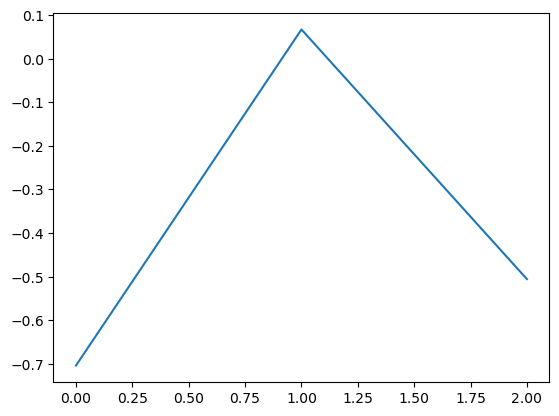

In [41]:
plt.plot(model.conv2.bias.cpu().detach().numpy())

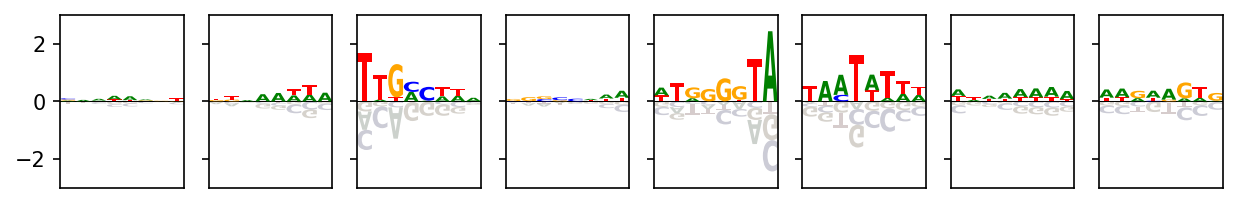

In [ ]:
def ShowLogo(ax, pwm):
    ## custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## plot the Logo
    pwm_logo = logomaker.Logo(pwm,
                              shade_below=.8,
                              fade_below=.8,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)
    
    return None
df_motif1 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
df_motif1 = df_motif1.sub(df_motif1.mean(axis=1), axis=0)  # Center each row
df_motif2 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[1]).T, columns=['A', 'C', 'G', 'T'])
df_motif2 = df_motif2.sub(df_motif2.mean(axis=1), axis=0)  # Center each row
df_motif3 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[2]).T, columns=['A', 'C', 'G', 'T'])
df_motif3 = df_motif3.sub(df_motif3.mean(axis=1), axis=0)  # Center each row
df_motif4 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[3]).T, columns=['A', 'C', 'G', 'T'])
df_motif4 = df_motif4.sub(df_motif4.mean(axis=1), axis=0)  # Center each row
df_motif5 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[4]).T, columns=['A', 'C', 'G', 'T'])
df_motif5 = df_motif5.sub(df_motif5.mean(axis=1), axis=0)  # Center each row
df_motif6 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[5]).T, columns=['A', 'C', 'G', 'T'])
df_motif6 = df_motif6.sub(df_motif6.mean(axis=1), axis=0)  # Center each row
df_motif7 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[6]).T, columns=['A', 'C', 'G', 'T'])
df_motif7 = df_motif7.sub(df_motif7.mean(axis=1), axis=0)  # Center each row
df_motif8 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[7]).T, columns=['A', 'C', 'G', 'T'])
df_motif8 = df_motif8.sub(df_motif8.mean(axis=1), axis=0)  # Center each row

fig, axes = plt.subplots(1, 8, figsize=(10, 1.5), dpi=150, sharey=True)

ShowLogo(axes[0], df_motif1)
ShowLogo(axes[1], df_motif2)
ShowLogo(axes[2], df_motif3)
ShowLogo(axes[3], df_motif4)
ShowLogo(axes[4], df_motif5)
ShowLogo(axes[5], df_motif6)
ShowLogo(axes[6], df_motif7)
ShowLogo(axes[7], df_motif8)





# ymin, ymax = ax.get_ylim()
# axes[0].vlines([5.5], ymin, ymax, color='black', lw=1)
# axes[1].vlines([7.5], ymin, ymax, color='black', lw=1)

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])
axes[4].set_xticks([])
axes[5].set_xticks([])
axes[6].set_xticks([])
axes[7].set_xticks([])

axes[3].set_ylim(-3, 3)

plt.show()